### Real-World Scenario
You are working as a Data Scientist in an Email Security Company.
- Your task is to build an Intelligent Email Analysis System that can:
    - Detect spam emails
    - Understand sentiment
    - Extract important entities
    - Predict next words
    - Build a chatbot for support
    - Columns:
    - label → spam / ham
    - message → text

🧠 TASK 1 
Objective
Understand dataset patterns.
- Tasks
    - Check dataset shape
    - Count spam vs ham
    - Find average message length
    - Plot word frequenc

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import os
print(os.listdir('/content'))

['.config', 'drive', 'sample_data']


In [3]:
import os
print(os.listdir('/content/drive/MyDrive'))

['IMG-20240804-WA0000.jpg', 'S50242200390405.pdf', 'CSE BTech 3rd &4th years R22 CS and SYLLABUS 2024-25  (6-02-2025).pdf.gdrive', 'Colab Notebooks', 'Apriori_2.py', 'Copy of CSE BTech 3rd &4th years R22 CS and SYLLABUS 2024-25  (6-02-2025).pdf.gdrive', '23B81A0523_DS 1.pdf', 'report_1758117564972.pdf', 'Screenshot_20250917-194243 (2).png', 'Screenshot_20250917-194243 (1).png', 'Screenshot_20250917-194243.png', 'IMG-20250919-WA0014.jpg', 'Screenshot_20250919-202335 (2).png', 'Screenshot_20250919-202335 (1).png', 'Screenshot_20250919-202335.png', 'report_1758295583089.pdf', 'Screenshot_20250920-204323 (2).png', 'Screenshot_20250920-204323 (1).png', 'Screenshot_20250920-204323.png', 'report_1758381299832.pdf', 'Screenshot_20250922-202350 (2).png', 'Screenshot_20250922-202350 (1).png', 'Screenshot_20250922-202350.png', 'report_1758552862123.pdf', 'Audio from Kiran', 'Abstract552[1].pdf', 'Abstract552[1] (2).gdoc', 'Abstract552[1] (1).gdoc', 'Abstract552[1].gdoc', 'Project Documentation St

In [4]:
# Load dataset
import pandas as pd

path = '/content/drive/My Drive/spam (1).csv'
df = pd.read_csv(path, encoding='latin-1')

In [5]:
# Keep required columns
df = df[['v1', 'v2']]
df.columns = ['label', 'message']

In [6]:
# Shape
print("Dataset Shape:", df.shape)

Dataset Shape: (5572, 2)


In [7]:
# Spam vs Ham count
print("\nLabel Distribution:")
print(df['label'].value_counts())


Label Distribution:
label
ham     4825
spam     747
Name: count, dtype: int64


In [8]:
# Message length
df['length'] = df['message'].apply(len)

In [9]:
# Average length
print("\nAverage Message Length:", df['length'].mean())


Average Message Length: 80.11880832735105


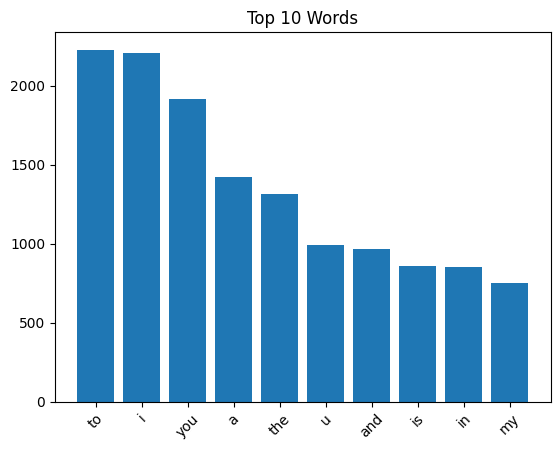

In [10]:
from collections import Counter
import matplotlib.pyplot as plt

words = " ".join(df['message']).lower().split()
freq = Counter(words)

common = dict(freq.most_common(10))

plt.figure()
plt.bar(common.keys(), common.values())
plt.xticks(rotation=45)
plt.title("Top 10 Words")
plt.show()

🧹 TASK 2 — Text Preprocessing Pipeline
- Build a reusable function that performs:
    - Lowercasing
    - Tokenization
    - Stopword removal
    - Punctuation removal
    - Lemmatization

- Bonus
    - Create a single pipeline function

    - def preprocess(text):
        ...
        return cleaned_text

In [14]:
import nltk

# These are the most commonly needed packages
nltk.download('punkt')          # For tokenization
nltk.download('stopwords')      # For removing common words (the, is, etc.)
nltk.download('wordnet')        # For lemmatization
nltk.download('omw-1.4')        # Support for wordnet
nltk.download('averaged_perceptron_tagger') # For POS tagging

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

import string

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.


### Pipeline Function

In [15]:
def preprocess(text):
    text = text.lower()
    words = word_tokenize(text)
    
    words = [w for w in words if w.isalnum()]        # remove punctuation
    words = [w for w in words if w not in stop_words] # remove stopwords
    words = [lemmatizer.lemmatize(w) for w in words] # lemmatization
    
    return " ".join(words)

### Preprocessing

In [20]:
import nltk

# These MUST be downloaded before you call .apply(preprocess)
nltk.download('punkt')         # Required for word_tokenize
nltk.download('stopwords')     # Required for stopwords.words('english')
nltk.download('wordnet')       # Required for WordNetLemmatizer
nltk.download('omw-1.4')       # Support for wordnet

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [21]:
# The correct way to run your preprocessing pipeline
df['clean_text'] = df['message'].apply(preprocess)

LookupError: 
**********************************************************************
  Resource [93mpunkt_tab[0m not found.
  Please use the NLTK Downloader to obtain the resource:

  [31m>>> import nltk
  >>> nltk.download('punkt_tab')
  [0m
  For more information see: https://www.nltk.org/data.html

  Attempted to load [93mtokenizers/punkt_tab/english/[0m

  Searched in:
    - '/root/nltk_data'
    - '/usr/nltk_data'
    - '/usr/share/nltk_data'
    - '/usr/lib/nltk_data'
    - '/usr/share/nltk_data'
    - '/usr/local/share/nltk_data'
    - '/usr/lib/nltk_data'
    - '/usr/local/lib/nltk_data'
**********************************************************************


🔢 TASK 3 — Feature Engineering (BoW vs TF-IDF)
- Ta- sks
    - Convert text using:
    - CountVectorizer (BoW)
    - TfidfVectorizer

- Compare:
    - Feature size
    - Sparsity
    - Model performance

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

### BoW

In [ ]:
bow = CountVectorizer()
X_bow = bow.fit_transform(df['clean_text'])

print("BoW Shape:", X_bow.shape)
print("BoW Sparsity:", X_bow.nnz / (X_bow.shape[0]*X_bow.shape[1]))

KeyError: 'clean_text'

🤖 TASK 4 — Baseline Model
- Build a simple model:
    - Algorithm: Logistic Regression
- Steps
    - Train model
    - Evaluate accuracy
    - Confusion matrix

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

# Encode labels
y = df['label'].map({'ham': 0, 'spam': 1})

# Split (use TF-IDF)
X_train, X_test, y_train, y_test = train_test_split(X_bow, y, test_size=0.2)

# Train
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.9757847533632287
Confusion Matrix:
 [[951   5]
 [ 22 137]]


📈 TASK 5 — Model Comparison
- Train multiple models:
    - Naive Bayes
    - Logistic Regression
    - SVM

- Compare:
    - Accuracy
    - Precision
    - Recall
    - F1-score

In [ ]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.metrics import classification_report

### Train Models

In [ ]:
models = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVM": SVC()
}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    
    print(f"\n{name}")
    print("Accuracy:", accuracy_score(y_test, preds))
    print(classification_report(y_test, preds))


Naive Bayes
Accuracy: 0.9775784753363229
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       956
           1       0.92      0.92      0.92       159

    accuracy                           0.98      1115
   macro avg       0.95      0.96      0.95      1115
weighted avg       0.98      0.98      0.98      1115


Logistic Regression
Accuracy: 0.9757847533632287
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       956
           1       0.96      0.86      0.91       159

    accuracy                           0.98      1115
   macro avg       0.97      0.93      0.95      1115
weighted avg       0.98      0.98      0.98      1115


SVM
Accuracy: 0.967713004484305
              precision    recall  f1-score   support

           0       0.97      1.00      0.98       956
           1       0.98      0.79      0.88       159

    accuracy                           0.97      1115
   

🧠 TASK 6 — Hyperparameter Tuning
- Use:
    - GridSearchCV
- Tune:
    - C (Logistic Regression)
    - kernel (SVM)

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

# Logistic Regression tuning
param_lr = {'C': [0.01, 0.1, 1, 10]}
grid_lr = GridSearchCV(LogisticRegression(max_iter=1000), param_lr, cv=3)
grid_lr.fit(X_train, y_train)

print("Best LR Params:", grid_lr.best_params_)

Best LR Params: {'C': 10}


In [ ]:
# SVM tuning
param_svm = {'kernel': ['linear', 'rbf']}
grid_svm = GridSearchCV(SVC(), param_svm, cv=3)
grid_svm.fit(X_train, y_train)

print("Best SVM Params:", grid_svm.best_params_)

Best SVM Params: {'kernel': 'linear'}


📊 TASK 7 — Advanced Feature Engineering
- Implement:
    - N-grams (bigram, trigram)
- Compare performance:
    - ngram_range=(1,2)
    - ngram_range=(1,3)

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Bigrams
tfidf_2 = TfidfVectorizer(ngram_range=(1,2))
X2 = tfidf_2.fit_transform(df['clean_text'])

# Trigrams
tfidf_3 = TfidfVectorizer(ngram_range=(1,3))
X3 = tfidf_3.fit_transform(df['clean_text'])

print("Bigram Shape:", X2.shape)
print("Trigram Shape:", X3.shape)

Bigram Shape: (5572, 37066)
Trigram Shape: (5572, 66278)


🧩 TASK 8 — Word Embeddings (Word2Vec)
- Tasks
    - Train Word2Vec model
    - Convert sentences → vectors (average embeddings)
    - Train classifier

In [ ]:
from gensim.models import Word2Vec

sentences = df['clean_text'].apply(lambda x: x.split())

w2v = Word2Vec(sentences, vector_size=100, window=5, min_count=1)

# Average embedding
import numpy as np

def get_avg_vector(words):
    vectors = [w2v.wv[w] for w in words if w in w2v.wv]
    return np.mean(vectors, axis=0) if vectors else np.zeros(100)

X_w2v = np.array([get_avg_vector(s) for s in sentences])

In [ ]:
from sklearn.model_selection import train_test_split

X_train_w2v, X_test_w2v, y_train, y_test = train_test_split(X_w2v, y, test_size=0.2)

model = LogisticRegression(max_iter=1000)
model.fit(X_train_w2v, y_train)

print("W2V Accuracy:", model.score(X_test_w2v, y_test))

W2V Accuracy: 0.8789237668161435


😊 TASK 9 — Sentiment Analysis
- Add new feature:
    - Sentiment score using TextBlob or VADER
    
Combine with TF-IDF.

In [ ]:
from textblob import TextBlob

df['sentiment'] = df['message'].apply(lambda x: TextBlob(x).sentiment.polarity)

In [ ]:
import numpy as np

X_combined = np.hstack((X_bow.toarray(), df['sentiment'].values.reshape(-1,1)))

🏷️ TASK 10 — Named Entity Recognition (NER)
- Extract entities from messages:
    - Names
    - Organizations
    - Locations
- Use:
    - spaCy

In [ ]:
import spacy

nlp = spacy.load("en_core_web_sm")

def extract_entities(text):
    doc = nlp(text)
    return [(ent.text, ent.label_) for ent in doc.ents]

df['entities'] = df['message'].apply(extract_entities)

print(df[['message', 'entities']].head())

                                             message  \
0  Go until jurong point, crazy.. Available only ...   
1                      Ok lar... Joking wif u oni...   
2  Free entry in 2 a wkly comp to win FA Cup fina...   
3  U dun say so early hor... U c already then say...   
4  Nah I don't think he goes to usf, he lives aro...   

                                            entities  
0                                   [(Cine, PERSON)]  
1                                                 []  
2  [(2, CARDINAL), (FA Cup, EVENT), (21st May 200...  
3                                 [(U dun, PRODUCT)]  
4                                                 []  


🔤 TASK 11 — Part-of-Speech Analysis
- Tasks
    - Extract POS tags
    - Find most common verbs/nouns in spam

In [ ]:
from collections import Counter

pos_counts = Counter()

for text in df['message']:
    doc = nlp(text)
    for token in doc:
        if token.pos_ in ['NOUN', 'VERB']:
            pos_counts[token.text.lower()] += 1

print(pos_counts.most_common(10))

[('call', 566), ('have', 389), ('get', 368), ('u', 358), ('go', 262), ('know', 258), ('come', 223), ('got', 220), ('do', 206), ('time', 206)]


🔮 TASK 12 — Language Model (N-gram)
- Build:
    - Bigram model to predict next word.
- Example:
    - "win money now" → predict

In [ ]:
from collections import defaultdict

bigram_model = defaultdict(lambda: defaultdict(int))

for sentence in df['clean_text']:
    words = sentence.split()
    for i in range(len(words)-1):
        bigram_model[words[i]][words[i+1]] += 1

# Prediction
def predict_next(word):
    if word in bigram_model:
        return max(bigram_model[word], key=bigram_model[word].get)
    return None

print(predict_next("win"))

cash
